In [4]:
import re
#Reading in the athinput file
def read_athinput(path):
    """Parse an Athena++ input file into a nested dict of {section: {key: value}}."""
    params = {}
    section = None
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            # Section header e.g. <problem>
            m = re.match(r'^<(\w+)>$', line)
            if m:
                section = m.group(1)
                if section != 'comment':
                    params[section] = {}
                continue
            # Key-value pair
            if section and section != 'comment' and '=' in line:
                key, _, rest = line.partition('=')
                value = rest.split('#')[0].strip()
                key = key.strip()
                try:
                    value = int(value)
                except ValueError:
                    try:
                        value = float(value)
                    except ValueError:
                        pass  # keep as string
                params[section][key] = value
    return params


In [5]:
#Computing the Jet's Luminosty and Energy
import numpy as np
import sympy as sp
M = 1 #Mass of the star in code units
R = 1 #Radius of the star in code units
c = 1 #Speed of light in code units
G = 1 #Gravitational constant in code units


p = read_athinput('/scratch/aripoll/athena/inputs/mhd/athinput.jet_blast')
print(p)

rho_j = p['problem']['jet_rho'] # M*R^-3
P_j = p['problem']['jet_p']  #G*M^2*R^-4
h = 1+ 4*(P_j/rho_j)
Gamma = p['problem']['jet_Gam']
v = c*np.sqrt(1-1/(Gamma**2))
r_inj = p['problem']['jet_rinj'] # R
th_inj = p['problem']['theta_0']

t_stop = p['problem']['t_stop'] # R/c



L_jet = rho_j*h*Gamma**2*v*np.pi*r_inj**2*np.sin(th_inj)**2
L_jet = sp.simplify(L_jet)

E_jet = L_jet*t_stop
print("The Jet's Luminosity is: ", L_jet)
print("The Jet's Energy is: ", E_jet )


{'job': {'problem_id': 'jet_blast'}, 'output1': {'file_type': 'hdf5', 'data_format': 'double', 'variable': 'prim,cons', 'dt': 0.005}, 'output2': {'file_type': 'hst', 'dt': 0.01}, 'time': {'cfl_number': 0.25, 'nlim': -1, 'tlim': 3.5, 'integrator': 'vl2', 'xorder': 2, 'ncycle_out': 10}, 'mesh': {'nx1': 1600, 'x1min': 0.001, 'x1max': 1.5, 'ix1_bc': 'outflow', 'ox1_bc': 'outflow', 'nx2': 900, 'x2min': 0.0, 'x2max': 6.283185307179586, 'ix2_bc': 'periodic', 'ox2_bc': 'periodic', 'nx3': 1, 'x3min': 0.0, 'x3max': 1.0, 'ix3_bc': 'outflow', 'ox3_bc': 'outflow', 'adapt_interval': 10}, 'meshblock': {'nx1': 10, 'nx2': 10, 'nx3': 1}, 'hydro': {'gamma': 1.3333333333333333, 'mp': 1}, 'problem': {'compute_error': 'false', 'star_radius': 1.0, 'poly_index': 3.0, 'poly_csv_path': '/scratch/aripoll/athena/polytrope_n3.00.csv', 'cs_factor': 1e-06, 'phi0': 0, 'theta_0': 0.15, 't_stop': 0.6, 'jet_rinj': 0.1, 'jet_Gam': 50, 'jet_rho': 0.01, 'jet_p': 1e-06, 'x1_0': 0.0, 'x2_0': 0.0, 'x3_0': 0.0, 'thr': 0.9, 'am

In [6]:
#now lets make some dimensionless quantities for the jet's luminosity and energy
import pandas as pd
Emc2 = E_jet / (M * c**2)

poly = pd.read_csv("/scratch/aripoll/athena/polytrope_n3.00.csv")
rho_poly = poly['rho']
P_poly = poly['P']*1e-6
r_poly = poly['r']
M_r = poly['m']
r_01 = np.where(r_poly==0.10001000100010901)

rho_01 = 10.270327653050474




L_tilde = rho_j/rho_01 * h *Gamma**2 * v* c**-3

L_tilde = sp.simplify(L_tilde)
print(Emc2)

AttributeError: partially initialized module 'pandas' from '/home/aripoll/venvs/athena-env/lib/python3.14/site-packages/pandas/__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)

yt : [WARNING  ] 2026-03-17 14:51:43,520 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-03-17 14:51:43,521 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-03-17 14:51:43,521 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-03-17 14:51:43,521 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-03-17 14:51:43,543 Parameters: current_time              = 1.0650013652647545
yt : [INFO     ] 2026-03-17 14:51:43,543 Parameters: domain_dimensions         = [1600  900    1]
yt : [INFO     ] 2026-03-17 14:51:43,543 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-03-17 14:51:43,544 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-03-17 14:51:43,544 Parameters: cosmological_simulation   = 0


jet_blast.out1.00213
1.0650013652647545 code_time
[('athena_pp', 'Etot'), ('athena_pp', 'dens'), ('athena_pp', 'mom1'), ('athena_pp', 'mom2'), ('athena_pp', 'mom3'), ('athena_pp', 'press'), ('athena_pp', 'r0'), ('athena_pp', 'rho'), ('athena_pp', 's0'), ('athena_pp', 'vel1'), ('athena_pp', 'vel2'), ('athena_pp', 'vel3')]
[('athena_pp', 'Etot'), ('athena_pp', 'cell_volume'), ('athena_pp', 'dens'), ('athena_pp', 'dr'), ('athena_pp', 'dtheta'), ('athena_pp', 'dz'), ('athena_pp', 'mom1'), ('athena_pp', 'mom2'), ('athena_pp', 'mom3'), ('athena_pp', 'path_element_r'), ('athena_pp', 'path_element_theta'), ('athena_pp', 'path_element_z'), ('athena_pp', 'press'), ('athena_pp', 'r'), ('athena_pp', 'r0'), ('athena_pp', 'rho'), ('athena_pp', 's0'), ('athena_pp', 'theta'), ('athena_pp', 'vel1'), ('athena_pp', 'vel2'), ('athena_pp', 'vel3'), ('athena_pp', 'volume'), ('athena_pp', 'z'), ('gas', 'averaged_density'), ('gas', 'cell_mass'), ('gas', 'cell_volume'), ('gas', 'density'), ('gas', 'density_gra

yt : [INFO     ] 2026-03-17 14:51:44,758 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-03-17 14:51:44,759 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-03-17 14:51:44,759 Setting origin='native' for cylindrical geometry.
yt : [INFO     ] 2026-03-17 14:51:44,761 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-03-17 14:51:44,761 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-03-17 14:51:44,761 Making a fixed resolution buffer of (('gas', 'pressure')) 800 by 800



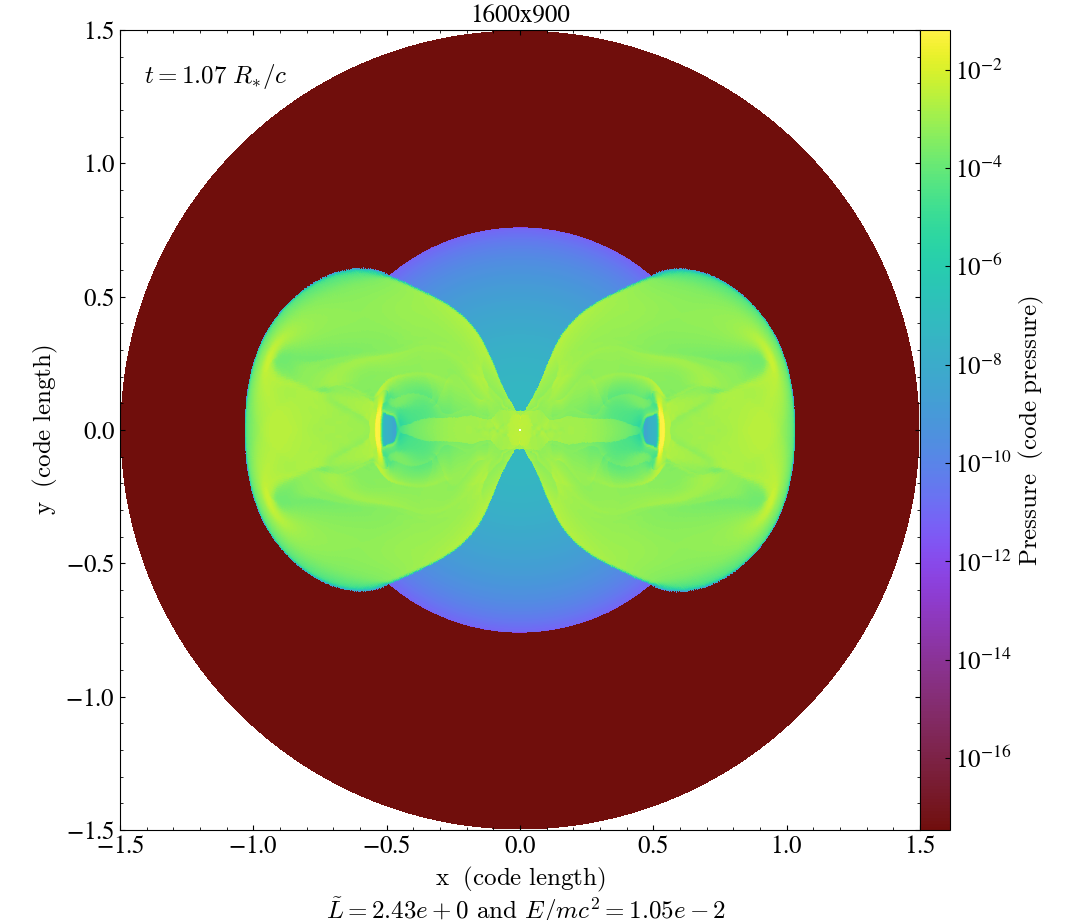

In [ ]:
import yt
from pathlib import Path
ds = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.00213.athdf')
nx, ny = ds.domain_dimensions[0], ds.domain_dimensions[1]
print(ds)
print(ds.current_time)
print(ds.field_list)        # native fields
print(ds.derived_field_list)
p = yt.SlicePlot(ds, "z", ("gas", "pressure"))
p.set_log(("gas", "pressure"), True)
p.annotate_timestamp(corner="upper_left", text_args={"color": "black"}, time_format=r"$t = {time:.2f}\ R_{{*}}/c$")
p.annotate_text((0.3, 0.001), rf"$\tilde{{L}}= {L_tilde:.2e} \text{{ and }} E/{{mc^2}}= {Emc2:.2e}$", coord_system="figure", text_args={"color": "black"})
p.annotate_title("{}x{}".format(nx, ny))


In [ ]:
# %%
ts = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.*.athdf')
nx, ny = ts[0].domain_dimensions[0], ts[0].domain_dimensions[1]
frames_dir = Path('/scratch/aripoll/athena_out/frames')
frames_dir.mkdir(parents=True, exist_ok=True)
print(len(ts))

for i, ds in enumerate(ts):
    p = yt.SlicePlot(ds, "z", ("gas", "pressure"))
    p.set_log(("gas", "pressure"), True)
    p.annotate_timestamp(corner="upper_left", text_args={"color": "black"}, time_format=r"$t = {time:.2f}\ R_{{*}}/c$")
    p.annotate_text((0.3, 0.001), rf"$\tilde{{L}}= {L_tilde:.2e} \text{{ and }} E/{{mc^2}}= {Emc2:.2e}$", coord_system="figure", text_args={"color": "black"})
    p.annotate_title("{}x{}".format(nx, ny))
    p.set_zlim(("gas","pressure"), 1e-17, 1e-2)
    p.save(frames_dir / f"press_frame_{i:05d}.png")
#%%


yt : [WARNING  ] 2026-03-17 12:17:43,560 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-03-17 12:17:43,561 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-03-17 12:17:43,561 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-03-17 12:17:43,561 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-03-17 12:17:43,587 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-03-17 12:17:43,588 Parameters: domain_dimensions         = [1600  900    1]
yt : [INFO     ] 2026-03-17 12:17:43,588 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-03-17 12:17:43,588 Parameters: domain_right_edge         = [1.5        6.28318548 1.        ]
yt : [INFO     ] 2026-03-17 12:17:43,589 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2026-03-17 12:17:43,593 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-03-17 12:17:43,594 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-03-17 12:17:43,594 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-03-17 12:17:43,594 Assuming 1.0 = 1.0 K
yt : [INFO     ] 20

701


yt : [INFO     ] 2026-03-17 12:17:44,848 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-03-17 12:17:44,849 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-03-17 12:17:44,849 Setting origin='native' for cylindrical geometry.
yt : [INFO     ] 2026-03-17 12:17:44,851 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-03-17 12:17:44,851 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-03-17 12:17:44,851 Making a fixed resolution buffer of (('gas', 'pressure')) 800 by 800
yt : [INFO     ] 2026-03-17 12:17:46,058 Saving plot /scratch/aripoll/athena_out/frames/press_frame_00000.png
yt : [WARNING  ] 2026-03-17 12:17:46,200 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-03-17 12:17:46,201 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-03-17 12:17:46,201 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-03-17 12:17:46,201 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-03-17 12:17:46,223 Parameters: current_time              = 0.005000255
yt : [INFO     ] 2026-03-17 12:17:46,223 Parameters: domain_dimensions         

In [ ]:
import yt
from pathlib import Path
import subprocess
ts = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.*.athdf')
frames_dir = Path('/scratch/aripoll/athena_out/frames')
frames_dir.mkdir(parents=True, exist_ok=True)
mp4_path = str("/scratch/aripoll/athena/gam_6_5_1600_900_t_06.mp4")
subprocess.run([
    "ffmpeg", "-y",
    "-framerate", "24",
    "-i", str(frames_dir / "press_frame_%05d.png"),
    "-c:v", "libx264",
    "-pix_fmt", "yuv420p",
    "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2",
    mp4_path
], check=True)

from IPython.display import Video, display
display(Video(mp4_path, embed=True))

ffmpeg version 4.4.4 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 12 (Gentoo 12.3.1_p20230526 p2)
  configuration: --prefix=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr --libdir=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr/lib64 --shlibdir=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr/lib64 --docdir=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr/share/doc/ffmpeg-4.4.4-r3/html --mandir=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr/share/man --enable-shared --cc=x86_64-pc-linux-gnu-gcc --cxx=x86_64-pc-linux-gnu-g++ --ar=x86_64-pc-linux-gnu-ar --nm=x86_64-pc-linux-gnu-nm --strip=x86_64-pc-linux-gnu-strip --ranlib=x86_64-pc-linux-gnu-ranlib --pkg-config=x86_64-pc-linux-gnu-pkg-config --optflags='-O2 -pipe -march=x86-64-v3 -O2 -ftree-vectorize -fno-math-errno -pipe -O2 -pipe' --disable-static --enable-avfilter --enable-avresample --disable-stripping --disable-optimizations --disable-libcelt --disable-indev=v4l2 --disable-outdev